# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [ ]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [ ]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [45]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [46]:
numbers = list(range(10))  # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) i random.shuffle(numbers)
print("До set_seed - 1:", random.randint(1, 100))
random.shuffle(numbers)
print("До set_seed (shuffle) - 1:", numbers)

print("До set_seed - 2:", random.randint(1, 100))
random.shuffle(numbers)
print("До set_seed (shuffle) - 2:", numbers)

set_seed()
print("Seed зафіксовано:", SEED)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ окремим генеруванням
set_seed()
print("Після set_seed (з повтором) - 1:", random.randint(1, 100))
numbers = list(range(10))
random.shuffle(numbers)
print("Після set_seed (shuffle) - 1:", numbers)

set_seed()
print("Після set_seed (з повтором) - 2:", random.randint(1, 100))
numbers = list(range(10))
random.shuffle(numbers)
print("Після set_seed (shuffle) - 2:", numbers)

# TODO: тепер ще двічі без проміжних викликів set_seed()
print("Без проміжного set_seed - 1:", random.randint(1, 100))
numbers = list(range(10))
random.shuffle(numbers)
print("Без проміжного set_seed (shuffle) - 1:", numbers)

print("Без проміжного set_seed - 2:", random.randint(1, 100))
numbers = list(range(10))
random.shuffle(numbers)
print("Без проміжного set_seed (shuffle) - 2:", numbers)

До set_seed - 1: 82
До set_seed (shuffle) - 1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
До set_seed - 2: 76
До set_seed (shuffle) - 2: [5, 8, 2, 1, 6, 3, 4, 0, 7, 9]
Seed зафіксовано: 42
Після set_seed (з повтором) - 1: 82
Після set_seed (shuffle) - 1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Після set_seed (з повтором) - 2: 82
Після set_seed (shuffle) - 2: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
Без проміжного set_seed - 1: 76
Без проміжного set_seed (shuffle) - 1: [4, 3, 2, 9, 5, 1, 7, 8, 0, 6]
Без проміжного set_seed - 2: 92
Без проміжного set_seed (shuffle) - 2: [5, 1, 9, 0, 2, 4, 7, 3, 6, 8]


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [ ]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [ ]:
# TODO: zeros_arr = np.zeros((3, 4))
# TODO: sevens_arr = np.full((3, 4), 7)
# 1. connect a library import numpy as np othervise "name 'np' is not defined
#https://numpy.org/doc/stable/user/absolute_beginners.html
import numpy as np
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [ ]:
# TODO: arange_arr = np.arange(0, 20, 2)
# TODO: linspace_arr = np.linspace(0, 1, 5)
import numpy as np
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [ ]:
# TODO: identity = np.eye(4)
# TODO: random_ints = np.random.randint(0, 10, size=(3, 3))

import numpy as np
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)
print("\nNDIM")
print(identity.ndim)
print(random_ints.ndim)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]

NDIM
2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [ ]:
import numpy as np

scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [ ]:

arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)

matrix = arr.reshape(3,4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [ ]:


df = pd.DataFrame({
    "student name": ["STUDENT 1", "STUDENT 2", "STUDENT 3", "STUDENT 4"],
    "score": [65, 85, 72, 96]
})

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html#

top = df[df["score"] > 80]
top = top.sort_values(by="score", ascending=False )
print(top)


  student name  score
3    STUDENT 4     96
1    STUDENT 2     85


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [ ]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"

def gradeabc(score):
  if score >=90:
    return "A"
  elif score >= 75 :
    return "B"
  else:
    return "C"


df["grade"] = df['score'].apply(gradeabc) #df['Salary'].apply(double_salary)
print(df)


  student name  score grade
0    STUDENT 1     65     C
1    STUDENT 2     85     B
2    STUDENT 3     72     C
3    STUDENT 4     96     A


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [ ]:
# TODO: zeros_t = torch.zeros((2, 3))
# TODO: sevens_t = torch.full((2, 3), 7)


zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t)
print(sevens_t)
print("\nSHAPE")
print(zeros_t.shape)
print(sevens_t.shape)
print("\nDTYPE")
print(zeros_t.dtype)
print(sevens_t.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[7, 7, 7],
        [7, 7, 7]])

SHAPE
torch.Size([2, 3])
torch.Size([2, 3])

DTYPE
torch.float32
torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [ ]:
# TODO: arange_t = torch.arange(0, 20, 2)
# TODO: linspace_t = torch.linspace(0, 1, 5)
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [ ]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print(random_t)

print("\nSHAPE")
print(from_list.shape)
print(random_t.shape)
print("\nDTYPE ")
print(from_list.dtype )
print(random_t.dtype )
print("\nDIM ")
print(from_list.ndim )
print(random_t.ndim )

tensor([[1, 2],
        [3, 4]])
tensor([[0.9221, 0.8527, 0.3290],
        [0.0054, 0.7739, 0.8333],
        [0.2315, 0.3323, 0.2376]])

SHAPE
torch.Size([2, 2])
torch.Size([3, 3])

DTYPE 
torch.int64
torch.float32

DIM 
2
2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [48]:
  n = 5.0

  # TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
  # надрукувати x.grad.item() і порівняти з 2 * n
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()
print("автоматичний градієнт:", x.grad.item())
print("аналітичний градієнт:", 2 * n)
print("співпадають:", x.grad.item() == 2 * n)


автоматичний градієнт: 10.0
аналітичний градієнт: 10.0
співпадають: True


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [ ]:




x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
#   loss = (x - 3) ** 2 + 5
#   loss.backward()
#   під torch.no_grad(): x -= lr * x.grad

for i in range(20 ):
  loss =(x-3) ** 2+ 5
  loss.backward()
  with torch.no_grad():
    x -= lr * x.grad
    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

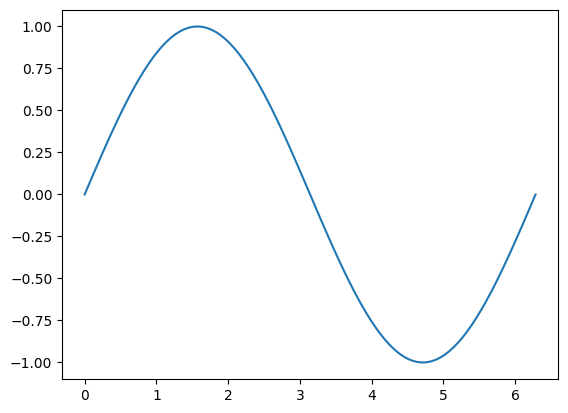

In [ ]:
# TODO: xs = np.linspace(0, 2*np.pi, 100), plt.plot(xs, np.sin(xs)), plt.show()
xs = np.linspace(0,2 * np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

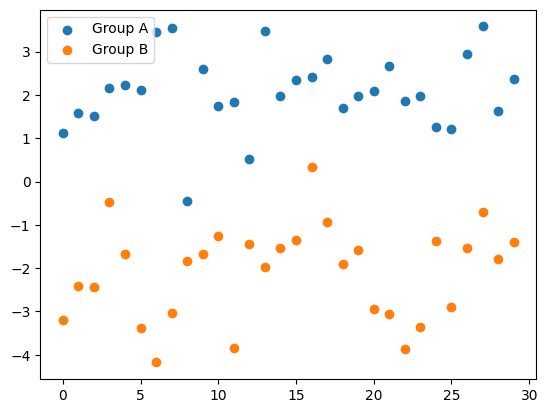

In [ ]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()
plt.scatter(range(30), group_a, color = "C0", label= "Group A") #blue
plt.scatter(range(30), group_b, color = "C1", label= "Group B") #red
plt.legend()
plt.show()



---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [ ]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise



**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

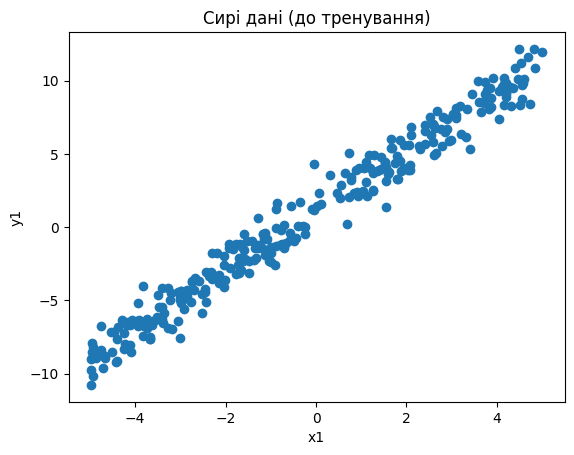

In [ ]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"
plt.scatter(x1, y1)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [ ]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...
##################################
idx = torch.randperm(TASK1_N)

x1_shuffled =x1[idx]
y1_shuffled =y1[idx]

train_end = int(0.70 * TASK1_N)
val_end = int(0.85 * TASK1_N)

x_train1, y_train1 = x1_shuffled[:train_end], y1_shuffled[:train_end]
x_val1, y_val1 = x1_shuffled[train_end:val_end], y1_shuffled[train_end:val_end]
x_test1, y_test1 = x1_shuffled[val_end:], y1_shuffled[val_end:]
##################################

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [ ]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=25.259396  w=1.8004 (true 2.0)  b=-0.0805 (true 1.0)
epoch   30  loss=0.873699  w=2.0204 (true 2.0)  b=0.9973 (true 1.0)
epoch   60  loss=0.870761  w=2.0217 (true 2.0)  b=1.0441 (true 1.0)
epoch   90  loss=0.870755  w=2.0218 (true 2.0)  b=1.0462 (true 1.0)
epoch   99  loss=0.870755  w=2.0218 (true 2.0)  b=1.0462 (true 1.0)


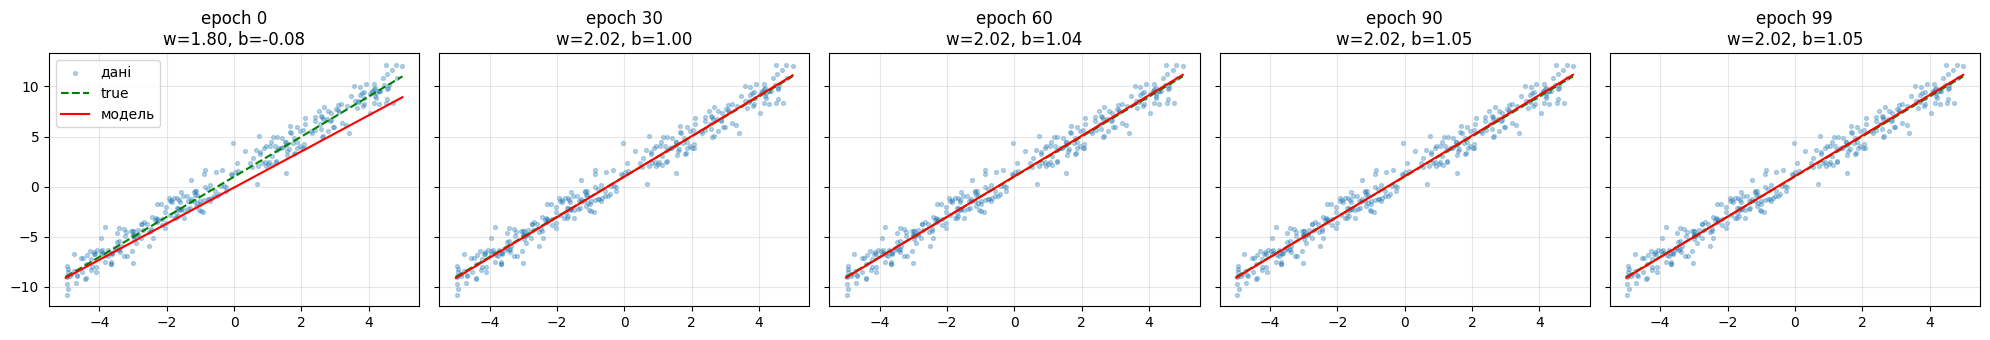

In [ ]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

### Сценарій
Я обрав залежність між кількістю годин навчання на тиждень та результатом тесту.
Вважаю, що приблизну залежність можна описати формулою:

y = 5x + 40 + $ε$

де:
- x - Це кількість годин навчання на тиждень
- y - Це результат тесту
- $w$ = 5 - Це кожна додаткова година навчання в середньому додає приблизно 5 балів
- $b$ = 40 - Це базовий рівень результату
- ε - Випадковий шум оскільки реальний результат залежить не тільки від часу навчання

Такі значення мені здаються правдоподібними, тому що більше часу на підготовку зазвичай покращує результат, але між студентами є і індивідуальні відмінності.

# CSV

In [ ]:
import torch
import pandas as pd
import numpy as np

TRUE_W = 5.0
TRUE_B = 40.0
N = 300

x = torch.empty(N, 1).uniform_(0, 10) #generates a random amount of studing hours 0 to 10

#adds random noise
noise = 5.0 * torch.randn(N, 1)
y = TRUE_W * x + TRUE_B + noise

#save data in csv
df = pd.DataFrame({"study_hours": x.squeeze().numpy(), "test_score": y.squeeze().numpy()})
df.to_csv("dataset.csv", index=False)
print(df.head())

print("finished")


   study_hours  test_score
0     4.018826   64.506935
1     0.867193   43.143955
2     6.343307   74.450905
3     1.978364   49.588917
4     5.181831   63.256710
finished


# Спліт даних

In [ ]:
def splitin_data(x, y):
	n = len(x)
	indices = torch.randperm(n)
	x = x[indices]
	y = y[indices]

	train_end = int(0.70 * n)
	val_end = int(0.85 * n)
	x_train = x[:train_end]
	y_train = y[:train_end]

	x_val = x[train_end:val_end]
	y_val = y[train_end:val_end]
	x_test = x[val_end:]
	y_test = y[val_end:]
	return x_train,y_train,x_val,y_val,x_test,y_test
x_train,y_train,x_val,y_val,x_test,y_test = splitin_data(x,y)

print(
  len(x_train),
	len(x_val),
	len(x_test)
)

210 45 45


#Функція для обучення моделі

In [ ]:
def train_model(x_train, y_train, epochs=200, lr=0.01):
    model = torch.nn.Linear(in_features=1, out_features=1)

    optimizer = torch.optim.SGD(model.parameters(),lr=lr)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0 or epoch == epochs - 1:
            print(
                f"epoch {epoch:3d}  "
                f"loss={loss.item():.4f}  "
                f"w={model.weight.item():.4f}  "
                f"b={model.bias.item():.4f}"
            )

    return model

In [ ]:
#model = train_model(x_train, y_train)
#epoch   0  loss=3668.3601  w=7.5072  b=2.1458
#epoch  50  loss=249.8498  w=9.2688  b=11.1586
#epoch 100  loss=159.1809  w=8.2799  b=17.7738
#epoch 150  loss=105.0089  w=7.5156  b=22.8871
#epoch 199  loss=73.1403  w=6.9351  b=26.7700

model = train_model(x_train, y_train, epochs=1000, lr=0.01)

epoch   0  loss=3969.9768  w=7.5222  b=0.7953
epoch  50  loss=271.3403  w=9.4496  b=10.1829
epoch 100  loss=172.9400  w=8.4114  b=17.0737
epoch 150  loss=113.8910  w=7.6072  b=22.4117
epoch 200  loss=78.4562  w=6.9842  b=26.5468
epoch 250  loss=57.1921  w=6.5016  b=29.7501
epoch 300  loss=44.4318  w=6.1277  b=32.2315
epoch 350  loss=36.7744  w=5.8381  b=34.1538
epoch 400  loss=32.1793  w=5.6138  b=35.6429
epoch 450  loss=29.4218  w=5.4400  b=36.7964
epoch 500  loss=27.7671  w=5.3053  b=37.6900
epoch 550  loss=26.7740  w=5.2010  b=38.3822
epoch 600  loss=26.1782  w=5.1203  b=38.9184
epoch 650  loss=25.8206  w=5.0577  b=39.3338
epoch 700  loss=25.6060  w=5.0092  b=39.6556
epoch 750  loss=25.4772  w=4.9716  b=39.9049
epoch 800  loss=25.4000  w=4.9425  b=40.0980
epoch 850  loss=25.3536  w=4.9200  b=40.2476
epoch 900  loss=25.3258  w=4.9025  b=40.3635
epoch 950  loss=25.3091  w=4.8890  b=40.4532
epoch 999  loss=25.2992  w=4.8787  b=40.5216


In [ ]:
with torch.no_grad():
    y_test_pred = model(x_test)
    test_loss = torch.nn.MSELoss()(y_test_pred, y_test)

print(f"Test MSE: {test_loss.item():.4f}")
print(f"learned W: {model.weight.item():.4f}")
print(f"learned B: {model.bias.item():.4f}")


Test MSE: 16.7562
learned W: 4.8787
learned B: 40.5216


**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [ ]:
torch.save(model.state_dict(), "model.pt")

**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [49]:
!pip install -q gradio
import gradio as gr

---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```